In [236]:
%pip install -qU scikit-learn numpy pandas matplotlib seaborn phik joblib category_encoders mlflow optuna jinja2 xgboost boto3

In [ ]:

import mlflow

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

import sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score, accuracy_score,
    classification_report, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import chi2_contingency

from xgboost import XGBClassifier

from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
mlflow.set_tracking_uri("https://mlflow.ru")
mlflow.set_experiment("fraud_detection_classification")

<Experiment: artifact_location='s3://s3-ds-20260425-fc91e6bce4/mlflow/8', creation_time=1784979206455, effective_trace_archival_retention=None, experiment_id='8', last_update_time=1784979206455, lifecycle_stage='active', name='fraud_detection_classification', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [239]:
RANDOM_STATE = 42
TARGET = 'fraud_flag'

In [240]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive монтирован


In [241]:

df = pd.read_csv('/content/drive/MyDrive/datasets/retail_fraud_detection_100k.csv', sep=',', decimal='.')

int_cols = df.select_dtypes(include=['integer']).columns
for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

float_cols = df.select_dtypes(include=['float']).columns
for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float32
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int8   
 9   transaction_frequency_24h         100000 non-null  int8   
 10  avg_transaction_amount_7d         100000 non-null  float32
 11  failed_transaction_count_24h      100000 non-null  in

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,53.02,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,38.00,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,147.45,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,58.22,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,114.46,3,866,0,0,0,1,0,0,0,Low


---

### EDA

In [242]:
print("Явные дубликаты строк:", df.duplicated().sum())

Явные дубликаты строк: 0


In [243]:
df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'])

df['year'] = df['transaction_timestamp'].dt.year
df['month'] = df['transaction_timestamp'].dt.month
df['day_num'] = df['transaction_timestamp'].dt.dayofweek

In [244]:
y_desc = df[TARGET].describe()
y_desc

,fraud_flag
count,100000.00
mean,0.48
std,0.50
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,1.00


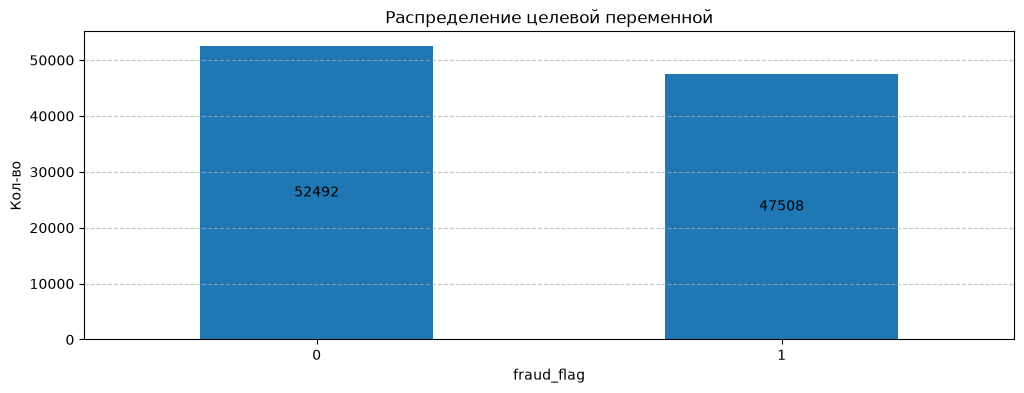

In [245]:
y_counts = df[TARGET].value_counts()

def show_bar(data, title):
    ax = data.plot(
        kind='bar',
        title=title,
        ylabel='Кол-во',
        rot=0,
        figsize=(12, 4)
    )

    ax.bar_label(ax.containers[0], label_type='center')
    ax.grid(axis='y', linestyle='--', alpha=.7)

    plt.show()
    plt.close()

show_bar(y_counts, 'Распределение целевой переменной')

In [246]:
print(f'Доля обыкновенных транзакций: {y_counts[0] / y_desc['count'] * 100:.0f}%')
print(f'Доля мошеннических транзакций: {y_counts[1] / y_desc['count'] * 100:.0f}%')

Доля обыкновенных транзакций: 52%
Доля мошеннических транзакций: 48%


In [247]:
def show_features(df, cols):
    table = []
    
    for col in cols:
        table.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': df[col].nunique(),
        })
    
    display(pd.DataFrame(table).sort_values('Кол-во', ascending=False))

In [248]:
def create_num_plot(df, col):
    cur_series = df[col]
    
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))
    
    hist = axes[0]
    cur_series.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    hist.set_title(f'Распределение: {cur_series.name}', fontsize=12)
    hist.set_xlabel('Значение')
    hist.set_ylabel('Количество')
    
    box = axes[1]
    sns.boxplot(
        data=cur_series,
        ax=box
    )
    box.set_title(f'Размах: {cur_series.name}', fontsize=12)
    box.set_ylabel('Значение')
    box.grid(True)
    box.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_num_plots(df, cols):
    for col in cols:
        create_num_plot(df, col)

In [249]:
def create_cat_plot(series):
    plt.figure(figsize=(12, 4))
    
    ax = sns.countplot(
        x=series,
        hue=series,
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)
        
    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_cat_plots(df, cols):
    for col in cols:
        create_cat_plot(df[col])

In [250]:
num_cols = df.select_dtypes('number').columns
cat_cols = df.select_dtypes('object').columns

In [251]:
show_features(df, num_cols)

,Признак,Уникальные значения,Кол-во
0,transaction_amount,"[56.31, 20.35, 48.72, 153.62, 115.32, 41.31, 5...",32371
3,avg_transaction_amount_7d,"[53.02, 38.0, 147.45, 58.22, 114.46, 91.97, 36...",17927
5,account_age_days,"[1054, 97, 779, 286, 866, 709, 1909, 656, 325,...",1990
2,transaction_frequency_24h,"[13, 3, 8, 14, 10, 11, 9, 7, 12, 2, 5, 1, 6, 4]",14
14,month,"[3, 1, 12, 11, 4, 6, 10, 7, 2, 9, 8, 5]",12
15,day_num,"[2, 0, 3, 1, 6, 4, 5]",7
4,failed_transaction_count_24h,"[4, 2, 3, 0, 1]",5
1,is_international,"[0, 1]",2
7,unusual_amount_flag,"[0, 1]",2
6,previous_fraud_flag,"[0, 1]",2


In [252]:
show_features(df, cat_cols)

,Признак,Уникальные значения,Кол-во
0,transaction_id,"[T0000001, T0000002, T0000003, T0000004, T0000...",100000
1,customer_id,"[C20953, C24133, C07165, C19310, C25019, C0866...",28955
4,location,"[Canada, India, UK, Australia, USA, Germany]",6
5,merchant_category,"[Fashion, Electronics, Travel, Gaming, Luxury,...",6
2,payment_method,"[Debit Card, Credit Card, PayPal, Google Pay, ...",5
3,device_type,"[Tablet, Mobile, Desktop]",3
6,fraud_risk,"[Medium, Low, High]",3


In [253]:
analytical_num_cols = []
analytical_cat_cols = []
useful_cols = []

for col in df.columns:
    if col in ['transaction_id', 'customer_id', 'transaction_timestamp']:
        continue

    useful_cols.append(col)

    if df[col].nunique() > 15:
        analytical_num_cols.append(col)
    else:
        analytical_cat_cols.append(col)

In [254]:
df = df[useful_cols]

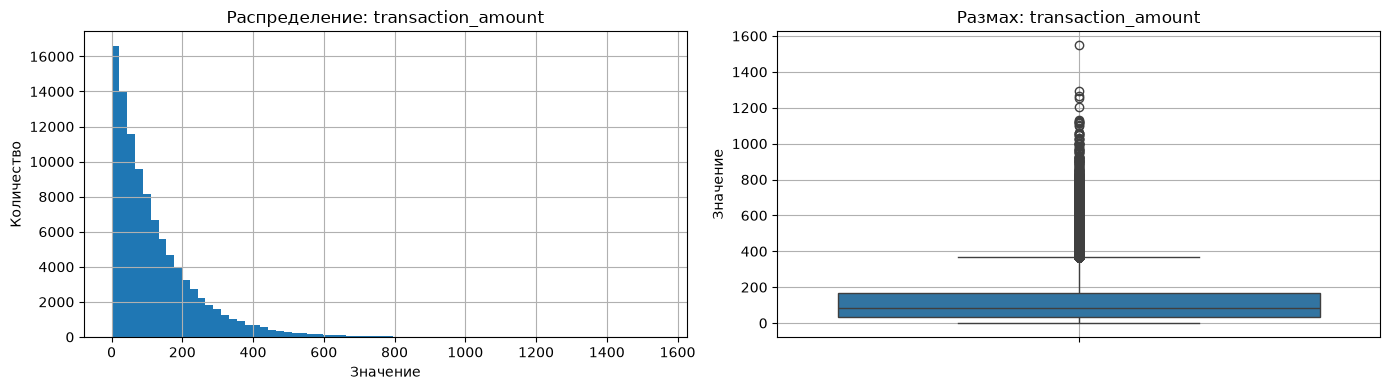

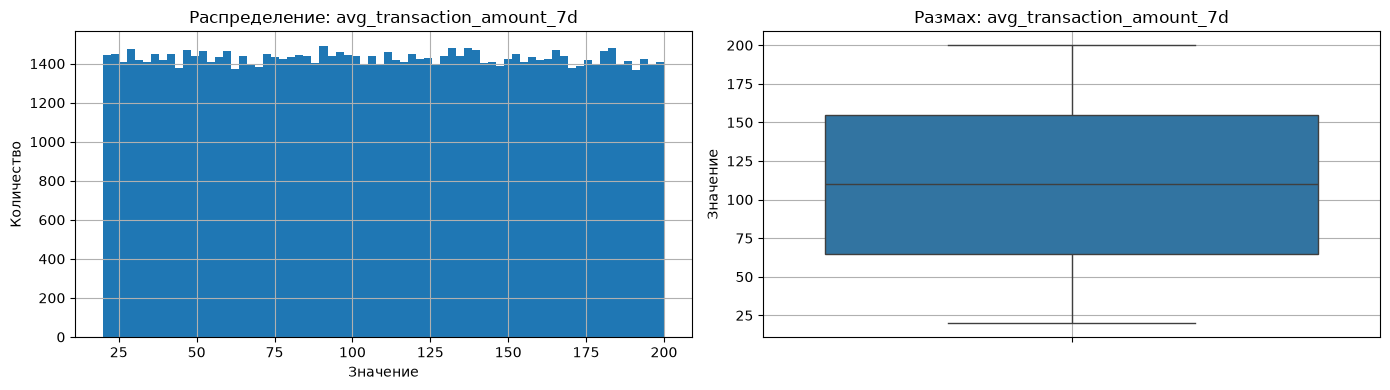

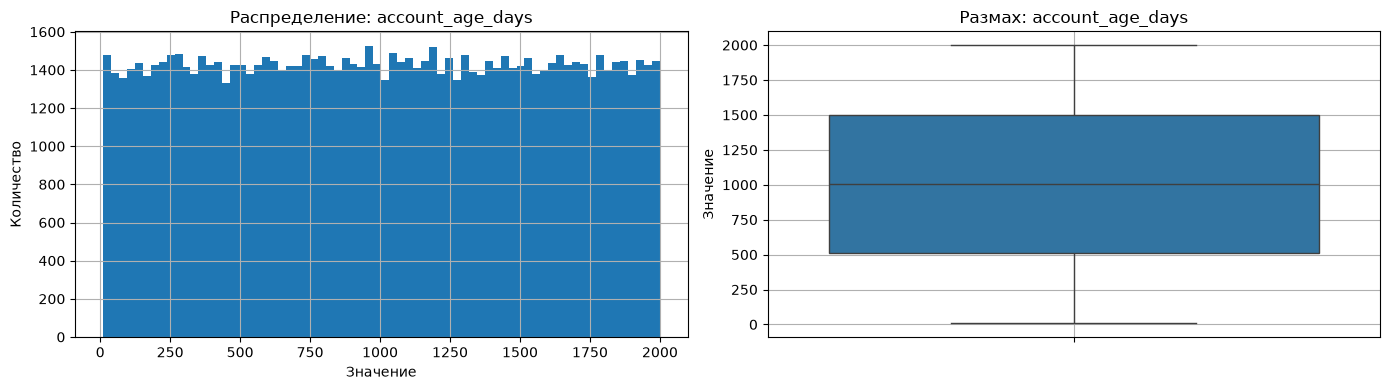

In [255]:
show_num_plots(df, analytical_num_cols)

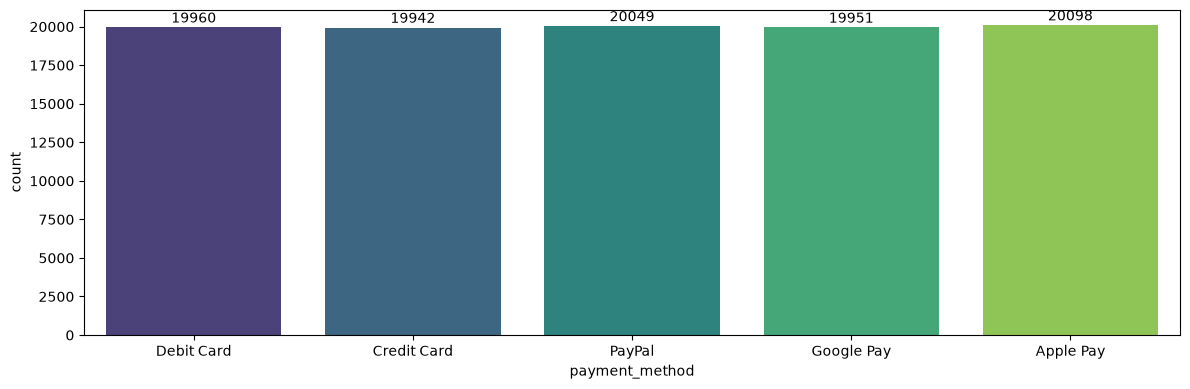

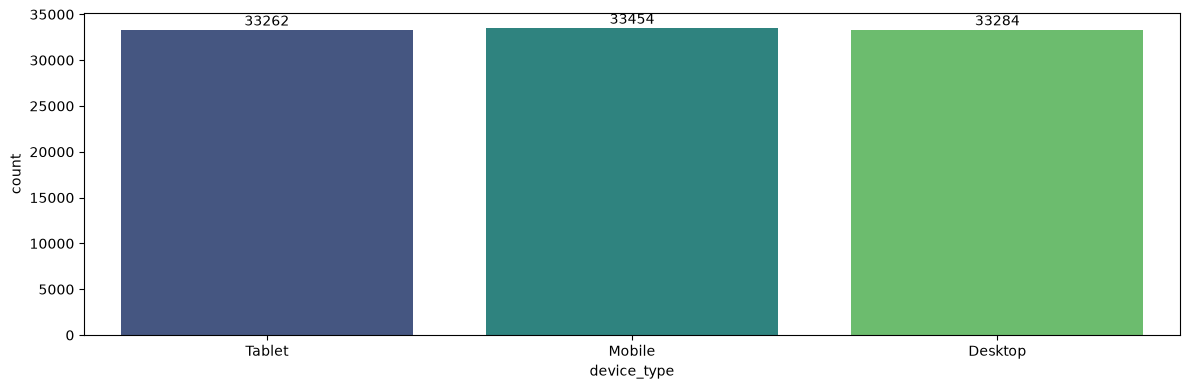

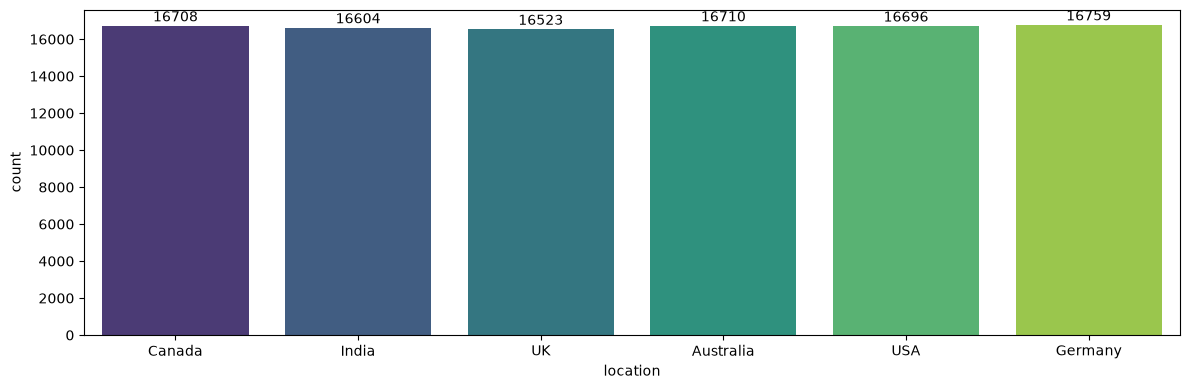

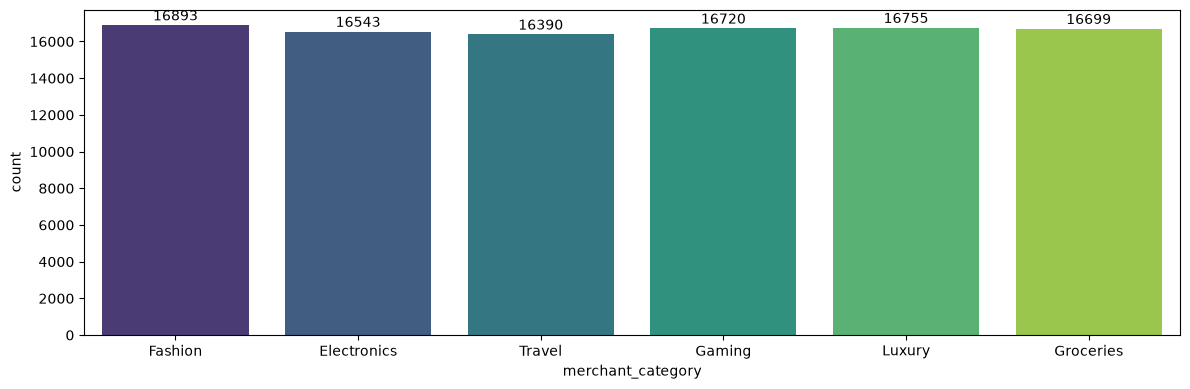

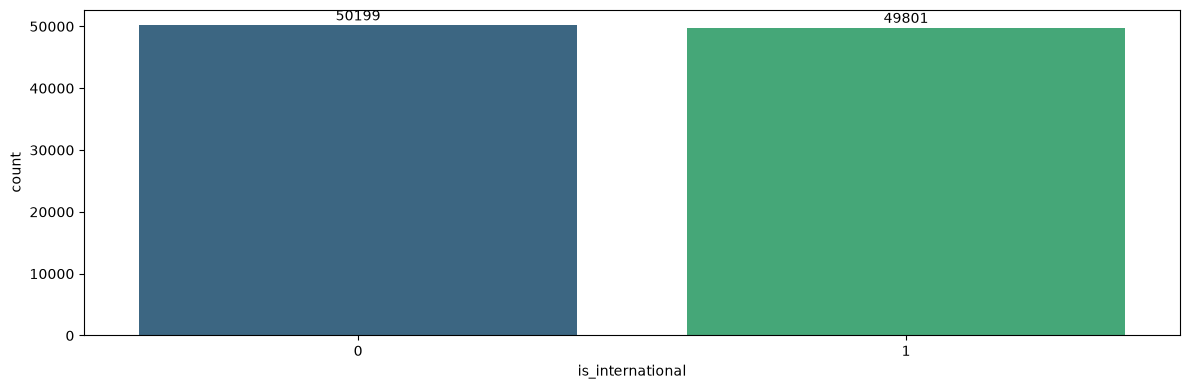

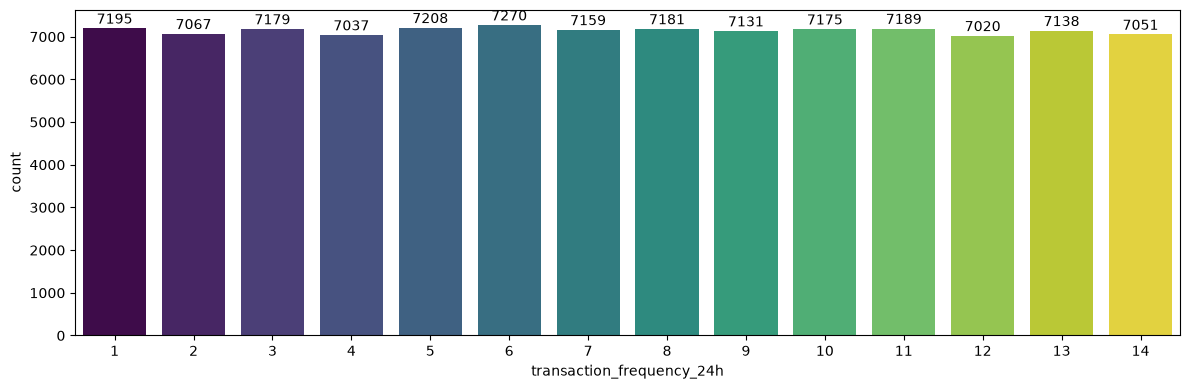

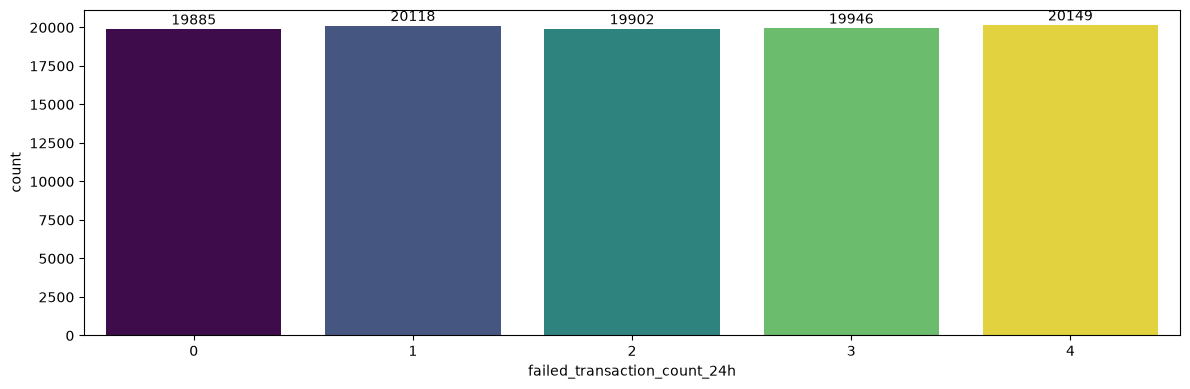

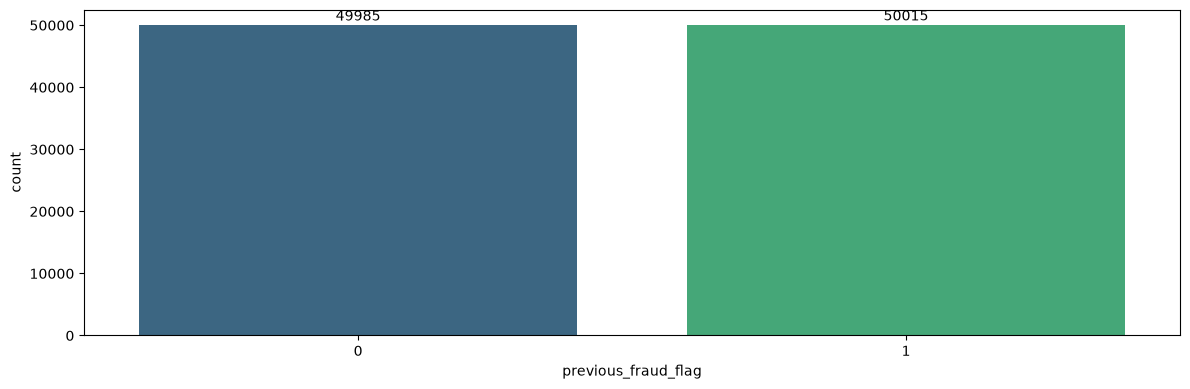

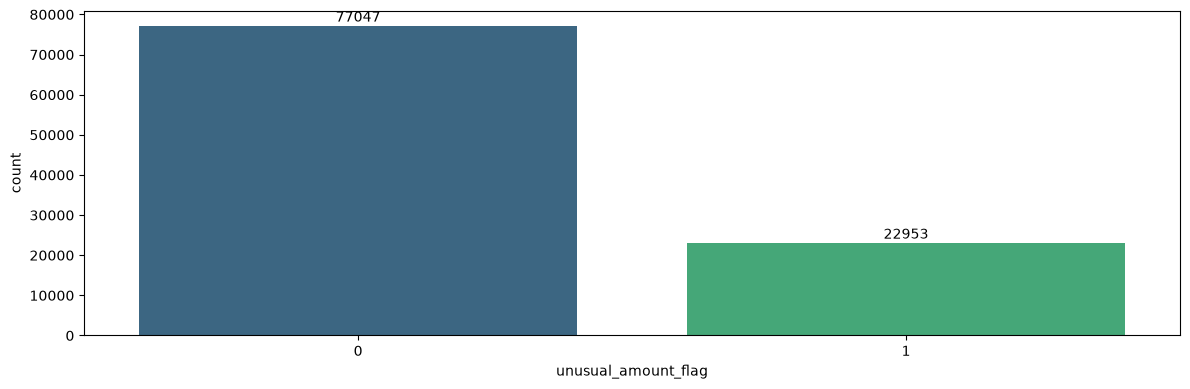

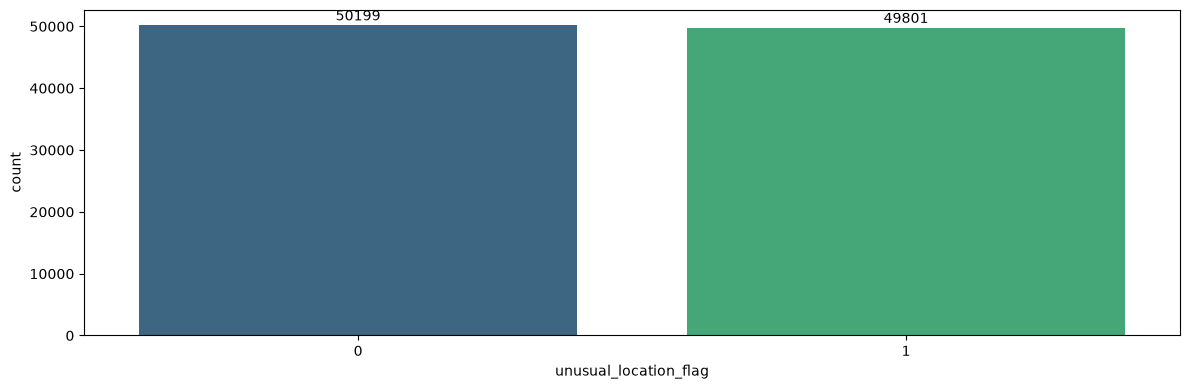

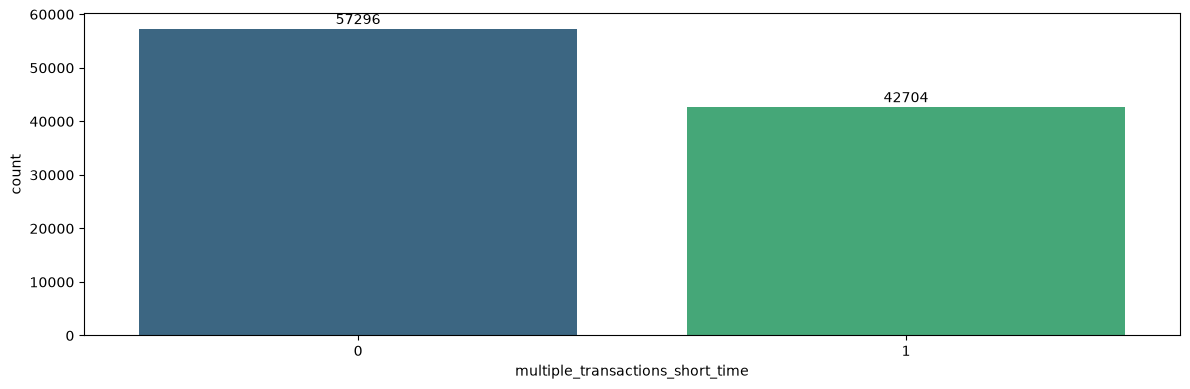

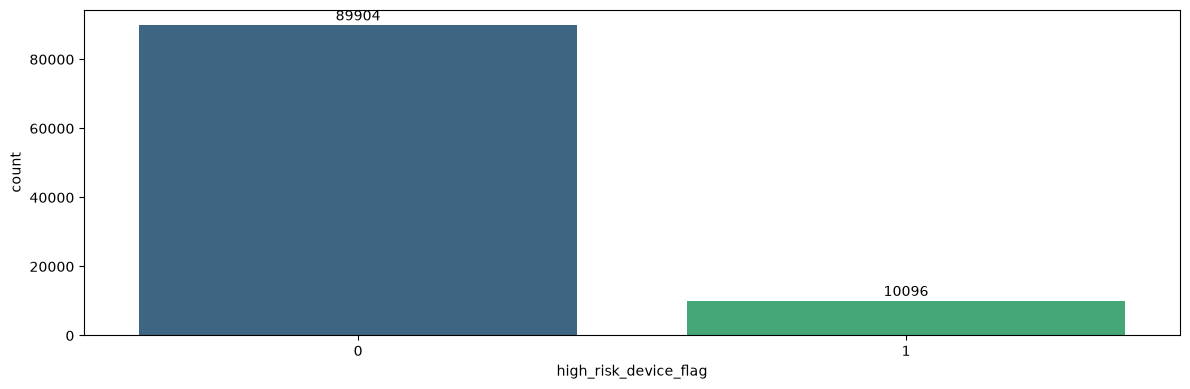

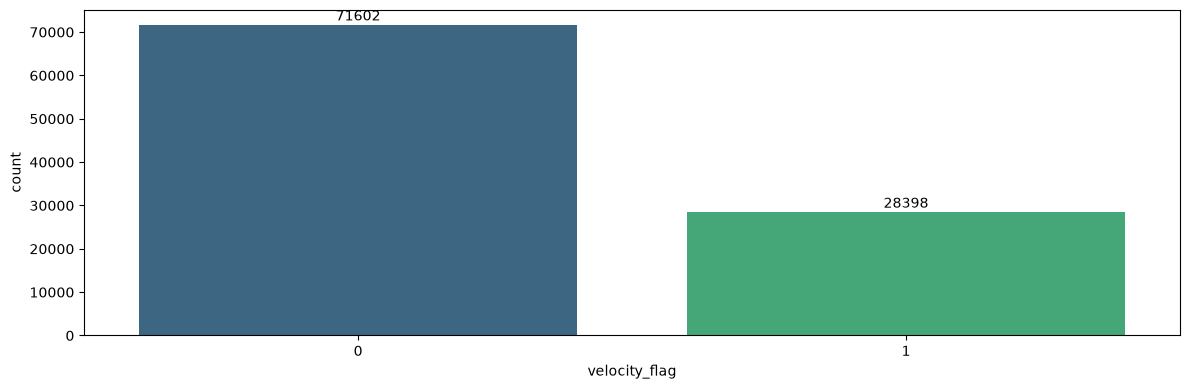

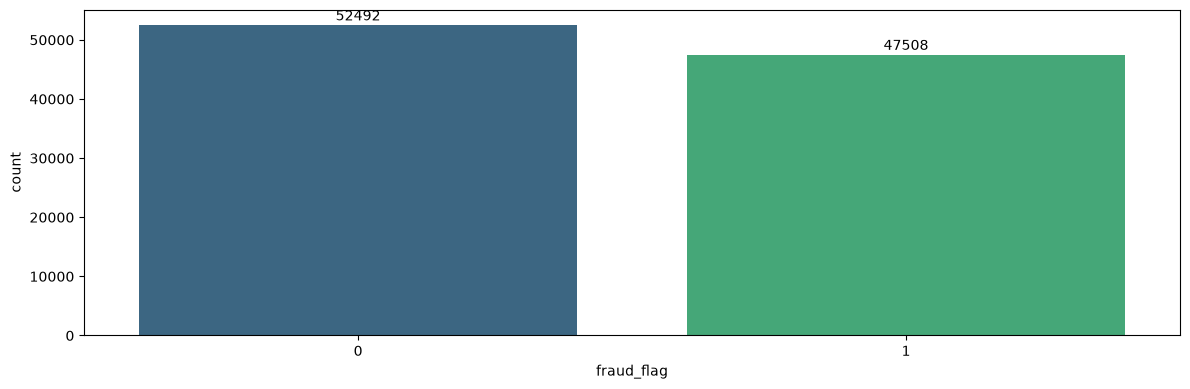

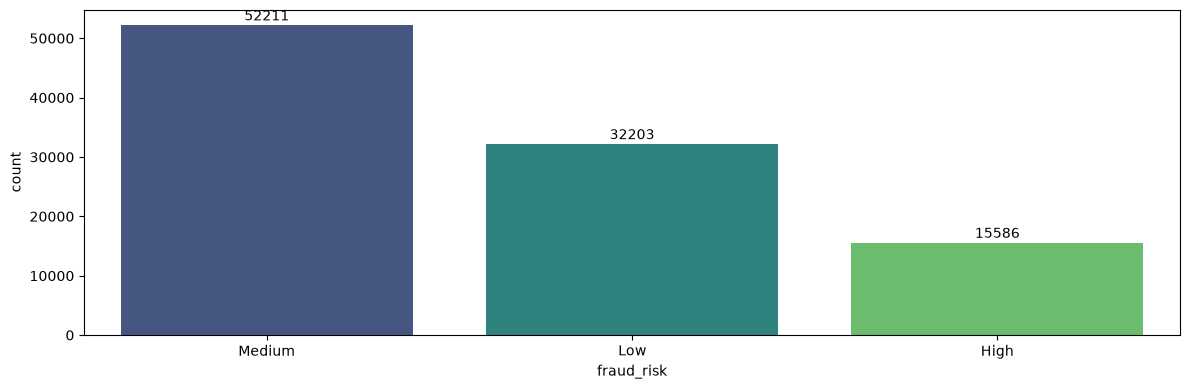

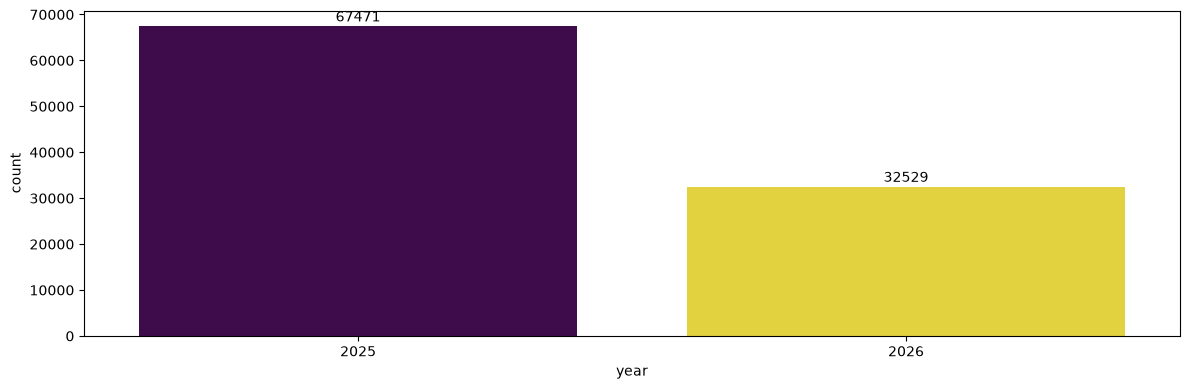

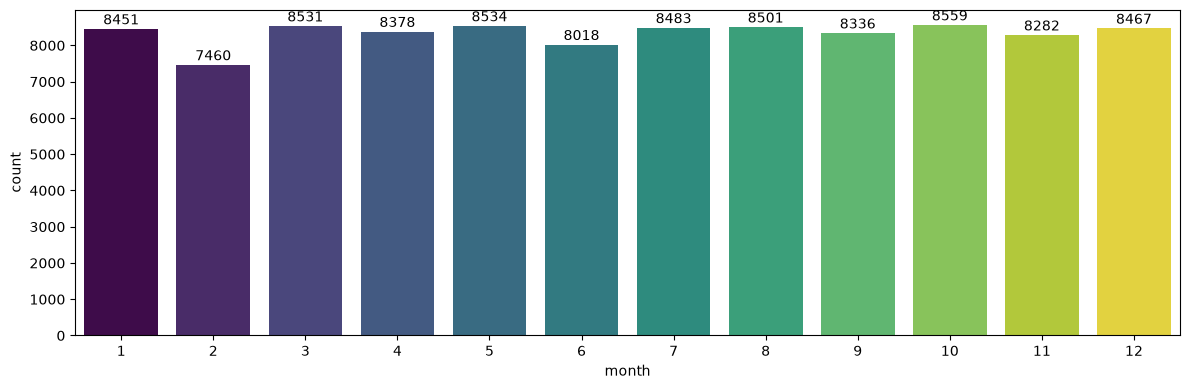

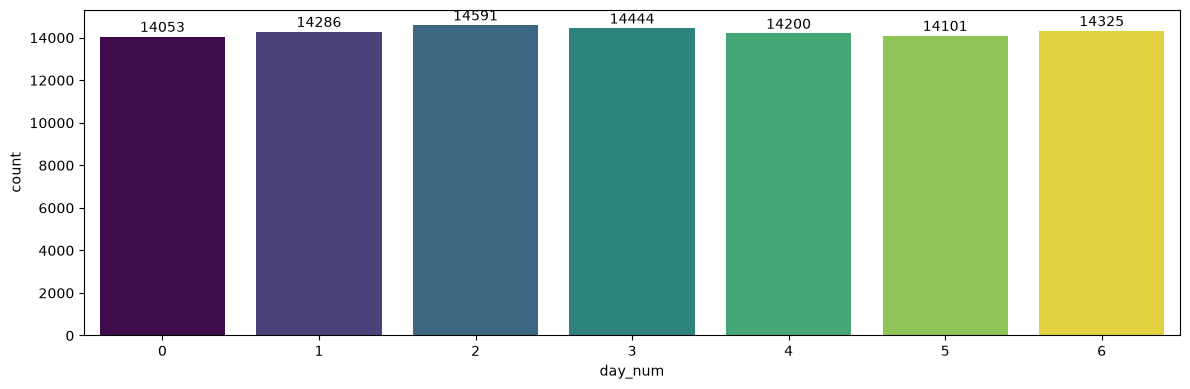

In [256]:
show_cat_plots(df, analytical_cat_cols)

#### Анализ корреляции

In [257]:
def show_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))
    
    sns.heatmap(
        corr, 
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False,
    )

    plt.title(title)
    plt.show()

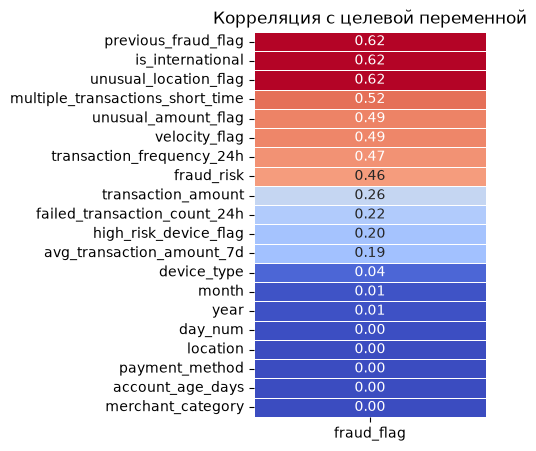

In [258]:
corr_matrix = df[useful_cols].phik_matrix(interval_cols=['transaction_amount', 'is_international', 'transaction_frequency_24h', 'avg_transaction_amount_7d', 'failed_transaction_count_24h', 'account_age_days', 'previous_fraud_flag', 'unusual_amount_flag', 'unusual_location_flag', 'multiple_transactions_short_time', 'high_risk_device_flag', 'velocity_flag', 'fraud_flag', 'year', 'month', 'day_num'])
target_corr = corr_matrix[corr_matrix.index != 'fraud_flag'][['fraud_flag']].sort_values(by='fraud_flag', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

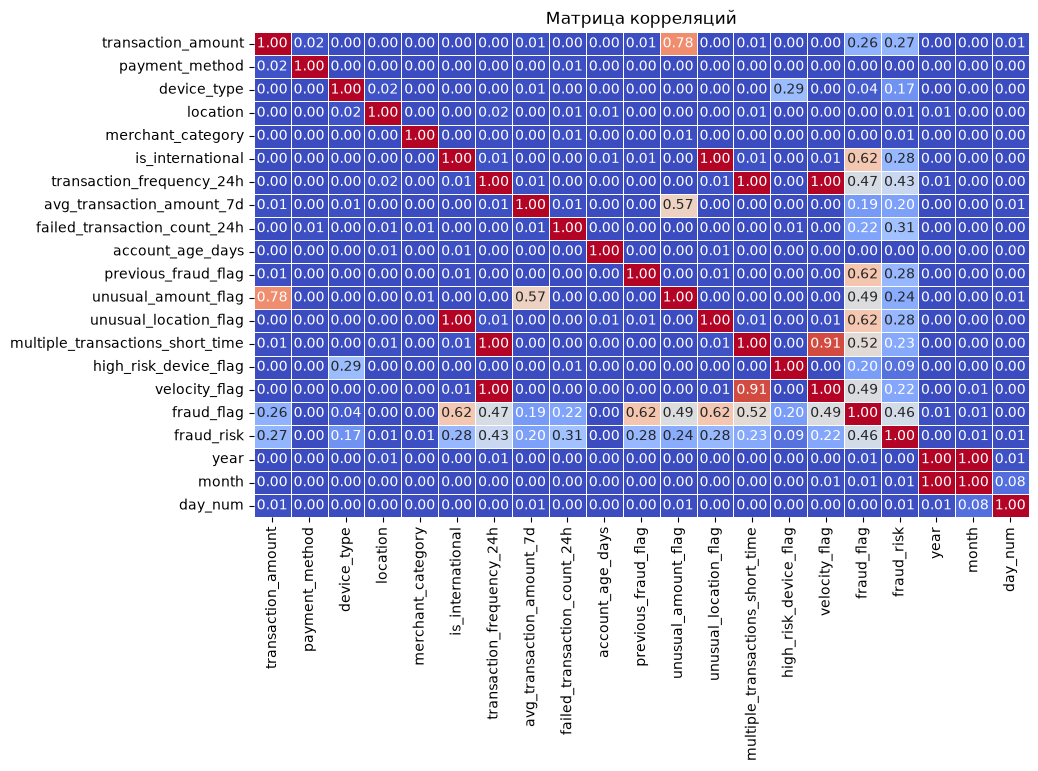

In [259]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=10, y_coef=.3)

Удаление мультиколлинеарности

In [260]:
df = df.drop(columns=['unusual_location_flag', 'multiple_transactions_short_time', 'velocity_flag'])

#### Проверка гипотез

is_international
Доля фрода по группам:
is_international
0   0.26
1   0.69
chi2 = 17883.64, p = 0 => значимо



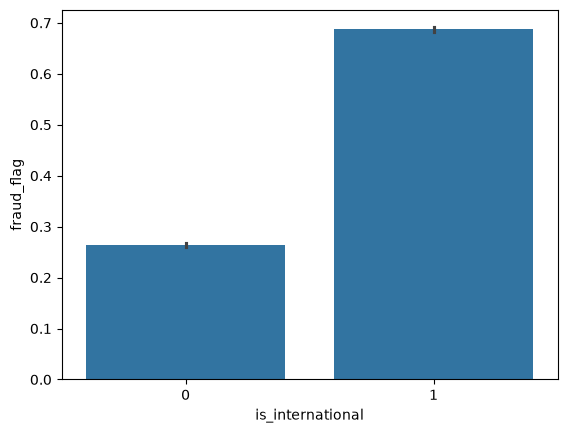

payment_method
Доля фрода по группам:
payment_method
Apple Pay     0.47
Credit Card   0.48
Debit Card    0.48
Google Pay    0.48
PayPal        0.47
chi2 = 1.20, p = 0.8783 => не значимо



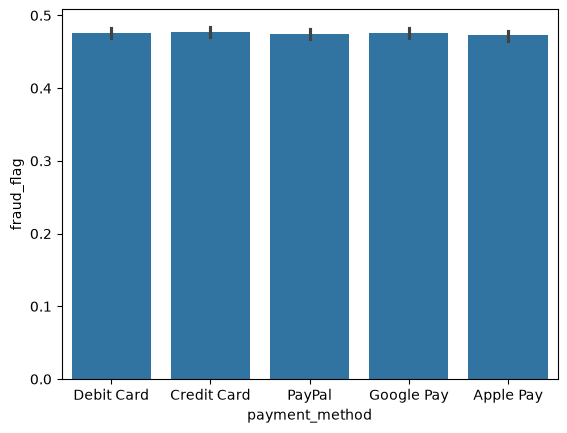

day_num
Доля фрода по группам:
day_num
0   0.47
1   0.47
2   0.47
3   0.47
4   0.47
5   0.48
6   0.48
chi2 = 6.72, p = 0.3476 => не значимо



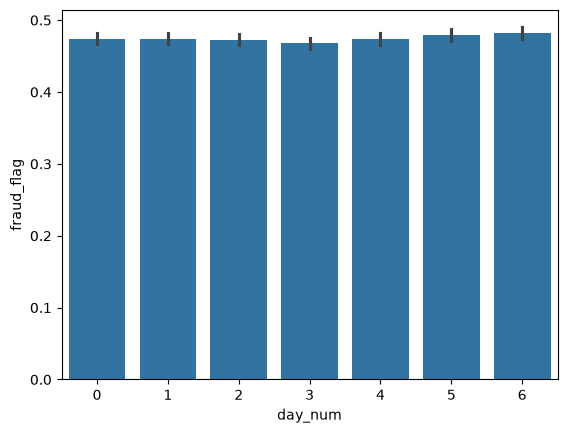

high_risk_device_flag
Доля фрода по группам:
high_risk_device_flag
0   0.45
1   0.66
chi2 = 1596.68, p = 0 => значимо



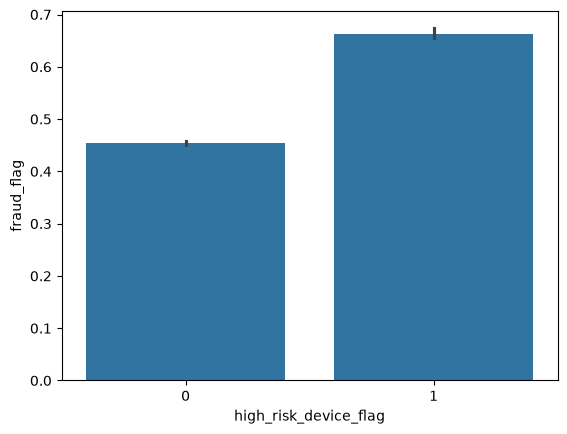

In [261]:
def test_hypothesis(df, feature, target='fraud_flag', alpha=.05):
    table = pd.crosstab(df[feature], df[target])
    chi2, p, _, _ = chi2_contingency(table)
    
    fraud_rate = df.groupby(feature)[target].mean()
    
    print(feature)
    print("Доля фрода по группам:")
    print(fraud_rate.to_string())
    print(f"chi2 = {chi2:.2f}, p = {p:.4g} => "
          f"{'значимо' if p < alpha else 'не значимо'}\n")
    
for feat in ['is_international', 'payment_method', 'day_num', 'high_risk_device_flag']:
    test_hypothesis(df, feat)
    sns.barplot(data=df, x=feat, y='fraud_flag')
    plt.show()
    plt.close()

Мошенничество чаще встречается при международных транзакциях и операциях с использованием устройств, относящихся к категории высокого риска; однако частота мошеннических операций не зависит от конкретных способов оплаты, равно как не наблюдается и повышенного уровня мошенничества в определенные дни недели.

---

### Предобработка

In [262]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].astype('category')

In [263]:
target = 'fraud_flag'

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=.2,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Среднее значенее целевой переменной в train: {y_train.mean():.3f}")
print(f"Среднее значенее целевой переменной в test: {y_test.mean():.3f}")

Размер обучающей выборки: (80000, 17)
Размер тестовой выборки: (20000, 17)
Среднее значенее целевой переменной в train: 0.473
Среднее значенее целевой переменной в test: 0.482


In [264]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [265]:
def plot_confusion_matrix(y_true, y_pred, name="Model"):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set(
        title=f"{name} — Confusion Matrix",
        xlabel="Предсказанные метки",
        ylabel="Актуальные метки",
    )
    fig.tight_layout()
    return fig


def plot_proba_distribution(y_true, y_prob, thresh=0.5, name="Model"):
    fig, ax = plt.subplots(figsize=(8, 6))
    df_probs = pd.DataFrame({'Probability': y_prob, 'Actual': list(y_true)})
    sns.histplot(
        data=df_probs, x='Probability', hue='Actual',
        element='step', kde=True, bins=30, ax=ax, palette='magma',
    )
    ax.axvline(thresh, color="red", linestyle="--", label=f'Порог {thresh:.2f}')
    ax.set(
        title=f"{name} — Вероятностное распределение по классам",
        xlabel="Предсказанная вероятность (1)",
        ylabel="Кол-во",
    )
    ax.legend(loc='upper left')
    fig.tight_layout()
    return fig


def show_ROC_curve(y_true, y_proba, score, name="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {score:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax.set(
        xlim=(0.0, 1.0), ylim=(0.0, 1.05),
        xlabel='False Positive Rate (FPR)',
        ylabel='True Positive Rate (TPR)',
        title=f'ROC-кривая: {name}',
    )
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig


def evaluate_model(estimator, X, y, cv, name="Model", thresh=0.5, log_to_mlflow=True):
    y_proba = cross_val_predict(
        estimator, X, y, cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]

    score = roc_auc_score(y, y_proba)
    y_pred = (y_proba >= thresh).astype(int)

    print(f"[{name}] CV ROC-AUC: {score:.4f}\n")
    print(classification_report(y, y_pred, zero_division=0))

    metrics = {
        "accuracy":  accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall":    recall_score(y, y_pred, zero_division=0),
        "f1":        f1_score(y, y_pred, zero_division=0),
        "roc_auc":   score,
    }

    figures = {
        "roc_curve":        show_ROC_curve(y, y_proba, score, name),
        "confusion_matrix": plot_confusion_matrix(y, y_pred, name),
        "proba_dist":       plot_proba_distribution(y, y_proba, thresh, name),
    }

    if log_to_mlflow and mlflow.active_run() is not None:
        mlflow.log_metrics(metrics)
        mlflow.log_param("threshold", thresh)
        for key, fig in figures.items():
            if fig is None:
                raise ValueError(f"Функция построения '{key}' вернула None - забыт return fig")
            mlflow.log_figure(fig, f"{key}.png")

    plt.show()
    return metrics, y_proba

In [266]:
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['category']).columns

In [267]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
    ],
    remainder='passthrough',
).set_output(transform='pandas')

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
    ],
    remainder='passthrough',
)

In [268]:
X_transformed_df = preprocessor.fit_transform(X_train)
X_transformed_df.head()

,num__transaction_amount,num__is_international,num__transaction_frequency_24h,num__avg_transaction_amount_7d,num__failed_transaction_count_24h,num__account_age_days,num__previous_fraud_flag,num__unusual_amount_flag,num__high_risk_device_flag,num__year,num__month,num__day_num,cat__payment_method_Credit Card,cat__payment_method_Debit Card,cat__payment_method_Google Pay,cat__payment_method_PayPal,cat__device_type_Mobile,cat__device_type_Tablet,cat__location_Canada,cat__location_Germany,cat__location_India,cat__location_UK,cat__location_USA,cat__merchant_category_Fashion,cat__merchant_category_Gaming,cat__merchant_category_Groceries,cat__merchant_category_Luxury,cat__merchant_category_Travel,cat__fraud_risk_Low,cat__fraud_risk_Medium
75220,0.22,-1.00,-1.11,1.35,0.71,0.37,-1.00,-0.54,-0.34,1.44,-1.60,1.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
48955,-0.97,1.00,0.63,1.06,1.41,-1.66,1.00,-0.54,-0.34,-0.70,0.72,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
44966,-0.93,-1.00,-1.11,-0.83,-0.71,-1.11,1.00,-0.54,-0.34,-0.70,1.59,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00
13568,-0.06,-1.00,-1.36,-0.27,0.71,0.80,1.00,-0.54,-0.34,-0.70,1.01,-1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
92727,1.21,1.00,1.37,-0.78,-0.00,-1.18,-1.00,1.84,2.98,-0.70,0.43,-1.51,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00


In [269]:
def run_optuna(build_pipeline_fn, build_best_pipeline_fn, name, n_trials=30):
    def objective(trial):
        pipeline = build_pipeline_fn(trial)
        scores = cross_val_score(
            pipeline, X_train, y_train,
            cv=cv, scoring="roc_auc", n_jobs=-1
        )
        return scores.mean()

    with mlflow.start_run(run_name=name):
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        fig1 = optuna.visualization.plot_optimization_history(study)
        fig2 = optuna.visualization.plot_param_importances(study)
        display(fig1)
        display(fig2)

        best_params = study.best_params
        print("Лучшие гиперпараметры:", best_params)
        print("Лучший CV ROC-AUC:", round(study.best_value, 4))

        mlflow.log_figure(fig1, f"{name}_optuna_history.html")
        mlflow.log_figure(fig2, f"{name}_param_importances.html")
        mlflow.log_metric("optuna_best_cv_roc_auc", study.best_value)
        mlflow.log_params(best_params)
        mlflow.log_param("n_trials", n_trials)

        best_pipeline = build_best_pipeline_fn(best_params)
        evaluate_model(best_pipeline, X_train, y_train, cv=cv, name=name)

        best_pipeline.fit(X_train, y_train)
        mlflow.sklearn.log_model(
            best_pipeline,
            name="model",
            input_example=X_train.iloc[:5],
            serialization_format="cloudpickle",
        )

[I 2026-07-25 13:50:54,687] A new study created in memory with name: no-name-5961d41a-c63c-4015-8e80-357aa4e35e67


  0%|          | 0/2 [00:00<?, ?it/s]

[I 2026-07-25 13:50:58,241] Trial 0 finished with value: 0.989486879338612 and parameters: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334}. Best is trial 0 with value: 0.989486879338612.
[I 2026-07-25 13:51:00,144] Trial 1 finished with value: 0.9894623328637564 and parameters: {'class_weight': None, 'tol': 0.008706020878304856, 'max_iter': 16984, 'solver': 'saga', 'C': 0.14077923139972406}. Best is trial 0 with value: 0.989486879338612.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.0029106359131330704, 'max_iter': 12776, 'solver': 'saga', 'C': 0.4042872735027334}
Лучший CV ROC-AUC: 0.9895
[LogReg] CV ROC-AUC: 0.9895

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     42129
           1       0.94      0.95      0.94     37871

    accuracy                           0.95     80000
   macro avg       0.95      0.95      0.95     80000
weighted avg       0.95      0.95      0.95     80000



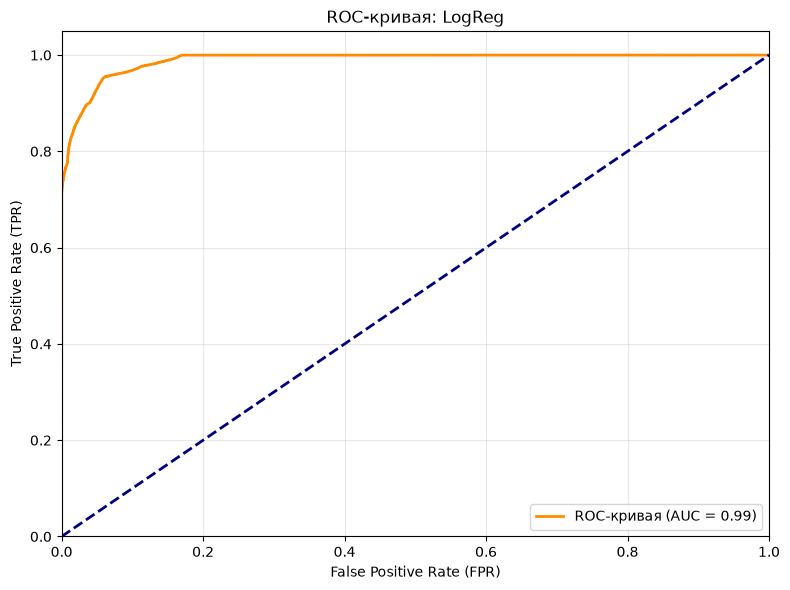

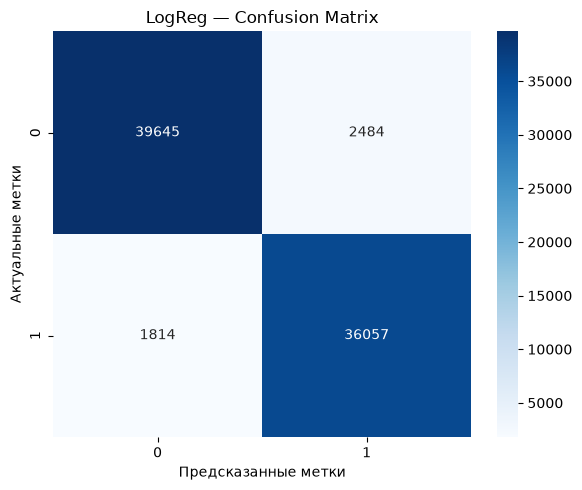

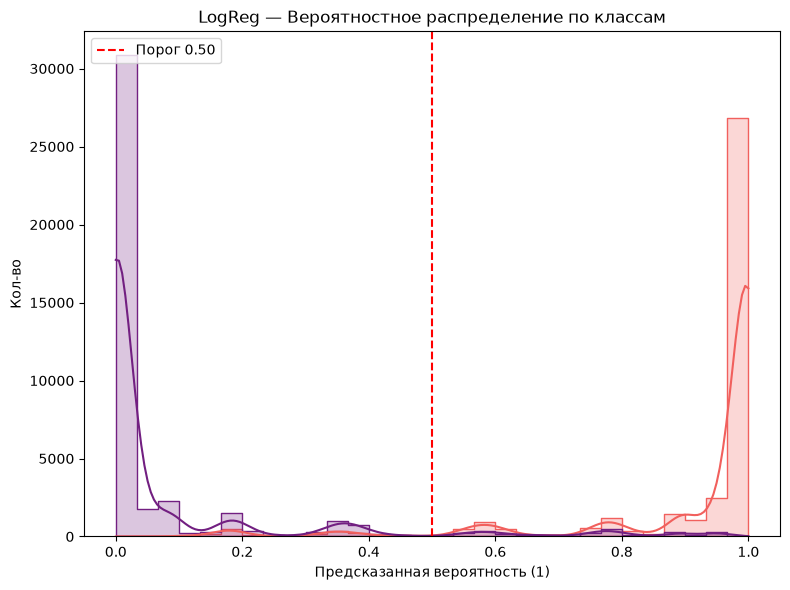

2026/07/25 13:51:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling

🏃 View run LogReg at: https://mlflow-ds-20260425-fc91e6bce4.infra.data-science.education-services.ru/#/experiments/8/runs/4226c0f2c2c54685b7d69c3b33afb243
🧪 View experiment at: https://mlflow-ds-20260425-fc91e6bce4.infra.data-science.education-services.ru/#/experiments/8


In [270]:
def build_pipeline_fn(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }
    
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(**params))
    ])

def build_best_pipeline_fn(best_params):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(**best_params, random_state=RANDOM_STATE))
    ])

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "LogReg", n_trials=2)

[I 2026-07-25 13:51:48,602] A new study created in memory with name: no-name-e0535e0d-d0ac-4911-b2aa-b1cac2853348


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-07-25 13:51:53,832] Trial 0 finished with value: 0.9952369734062227 and parameters: {'n_estimators': 56, 'max_depth': 15, 'min_samples_leaf': 160, 'min_samples_split': 200, 'max_features': 'sqrt', 'max_samples': 0.47323522915498706, 'min_impurity_decrease': 0.00025378155082656634, 'ccp_alpha': 0.0006796578090758161}. Best is trial 0 with value: 0.9952369734062227.
[I 2026-07-25 13:51:57,638] Trial 1 finished with value: 0.9961394069972288 and parameters: {'n_estimators': 31, 'max_depth': 15, 'min_samples_leaf': 175, 'min_samples_split': 103, 'max_features': 0.3, 'max_samples': 0.40495128632644756, 'min_impurity_decrease': 5.34293726127978e-05, 'ccp_alpha': 1.461896279370496e-05}. Best is trial 1 with value: 0.9961394069972288.
[I 2026-07-25 13:52:03,457] Trial 2 finished with value: 0.9894935532721003 and parameters: {'n_estimators': 73, 'max_depth': 6, 'min_samples_leaf': 94, 'min_samples_split': 141, 'max_features': 'log2', 'max_samples': 0.4028468876827223, 'min_impurity_dec

Лучшие гиперпараметры: {'n_estimators': 31, 'max_depth': 15, 'min_samples_leaf': 175, 'min_samples_split': 103, 'max_features': 0.3, 'max_samples': 0.40495128632644756, 'min_impurity_decrease': 5.34293726127978e-05, 'ccp_alpha': 1.461896279370496e-05}
Лучший CV ROC-AUC: 0.9961
[RandomForest] CV ROC-AUC: 0.9957

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     42129
           1       0.93      0.97      0.95     37871

    accuracy                           0.95     80000
   macro avg       0.95      0.95      0.95     80000
weighted avg       0.95      0.95      0.95     80000



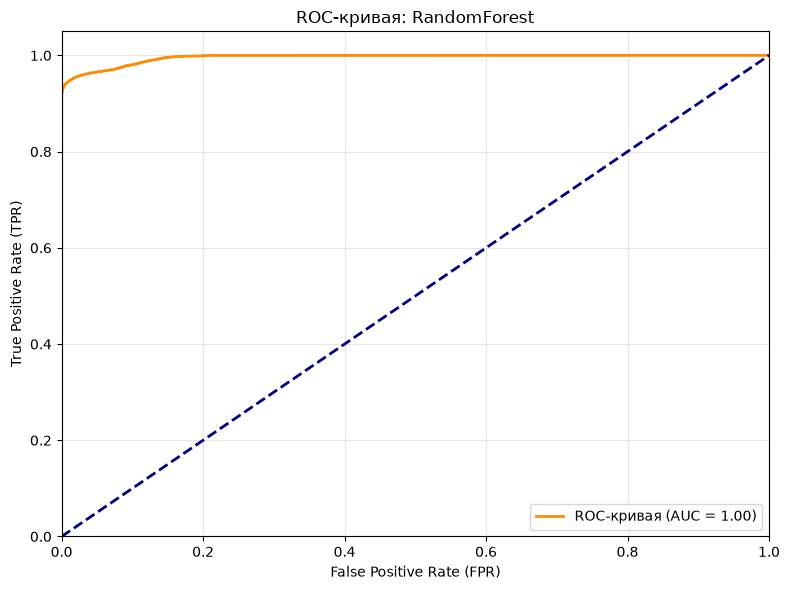

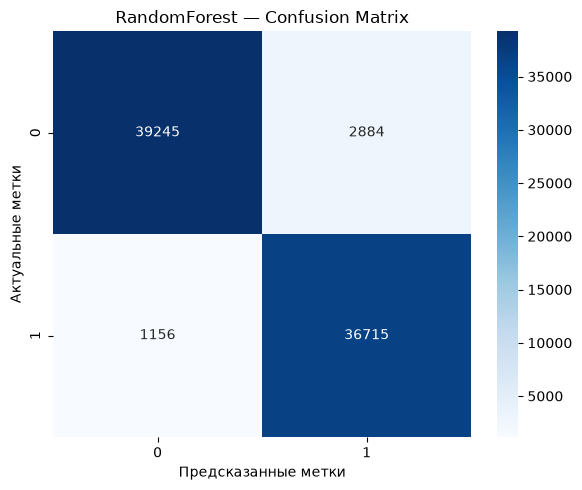

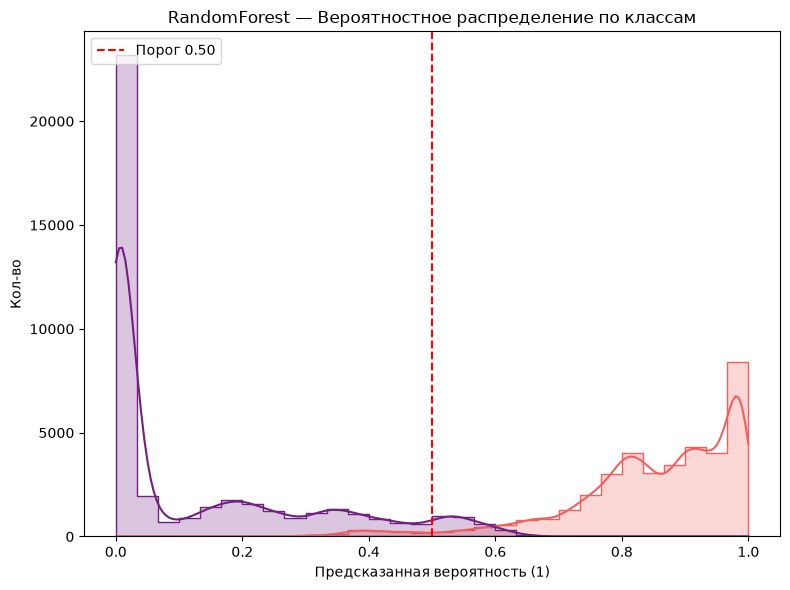

2026/07/25 13:52:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling

🏃 View run RandomForest at: https://mlflow-ds-20260425-fc91e6bce4.infra.data-science.education-services.ru/#/experiments/8/runs/99087f1eddad45fcbe9d77fcffdce9fa
🧪 View experiment at: https://mlflow-ds-20260425-fc91e6bce4.infra.data-science.education-services.ru/#/experiments/8


In [271]:
def build_pipeline_fn(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 30, 100),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 50, 200),
        "min_samples_split": trial.suggest_int("min_samples_split", 50, 300),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3]),
        "bootstrap": True,
        "max_samples": trial.suggest_float("max_samples", 0.3, 0.5),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-6, 1e-2, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-6, 1e-2, log=True),
        "criterion": "gini",
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }

    return Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('model', RandomForestClassifier(**params))
    ])

def build_best_pipeline_fn(best_params):
    return Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('model', RandomForestClassifier(**best_params))
    ])

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "RandomForest", n_trials=3)

[I 2026-07-25 13:52:53,296] A new study created in memory with name: no-name-ed55bb8b-0b5d-48b3-a719-313f05217430


  0%|          | 0/3 [00:00<?, ?it/s]

[I 2026-07-25 13:53:06,904] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'grow_policy': 'depthwise', 'subsample': 0.5290418060840998, 'colsample_bytree': 0.9330880728874675, 'colsample_bylevel': 0.8005575058716043, 'gamma': 3.540362888980227, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285, 'scale_pos_weight': 8.491983767203795}. Best is trial 0 with value: 1.0.
[I 2026-07-25 13:53:21,841] Trial 1 finished with value: 0.9901767937150382 and parameters: {'n_estimators': 503, 'learning_rate': 0.002820996133514492, 'max_depth': 4, 'min_child_weight': 4, 'grow_policy': 'depthwise', 'subsample': 0.645614570099021, 'colsample_bytree': 0.8059264473611898, 'colsample_bylevel': 0.569746930326021, 'gamma': 1.4607232426760908, 'reg_alpha': 1.9826980964985924e-05, 'reg_lambda': 0.00012724181576752517, 'scale_pos_weight': 8.066583652537123}. Best is trial 0 with value: 1.0.
[

Лучшие гиперпараметры: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'grow_policy': 'depthwise', 'subsample': 0.5290418060840998, 'colsample_bytree': 0.9330880728874675, 'colsample_bylevel': 0.8005575058716043, 'gamma': 3.540362888980227, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285, 'scale_pos_weight': 8.491983767203795}
Лучший CV ROC-AUC: 1.0
[XGBoost] CV ROC-AUC: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42129
           1       1.00      1.00      1.00     37871

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000



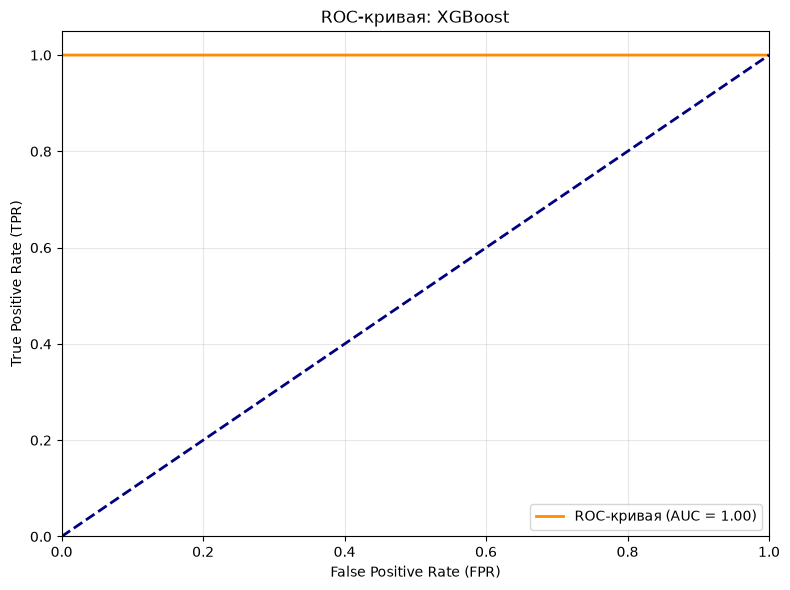

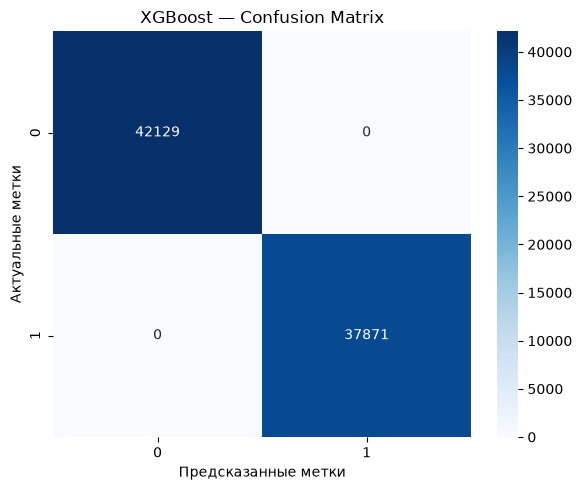

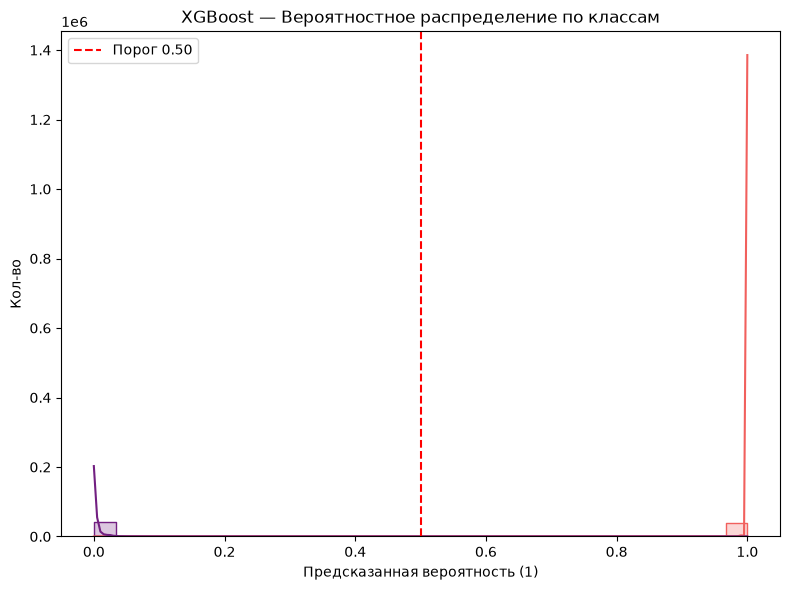

2026/07/25 13:54:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling

🏃 View run XGBoost at: https://mlflow-ds-20260425-fc91e6bce4.infra.data-science.education-services.ru/#/experiments/8/runs/f56f4d7729e94b0eb1989868cfcc20c8
🧪 View experiment at: https://mlflow-ds-20260425-fc91e6bce4.infra.data-science.education-services.ru/#/experiments/8


In [272]:
def build_pipeline_fn(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 10.0),
        "booster": "gbtree",
        "tree_method": "auto",
        "objective": "binary:logistic",
        "random_state": RANDOM_STATE,
        "verbosity": 0,
        "n_jobs": -1
    }

    return XGBClassifier(**params)

def build_best_pipeline_fn(best_params):
    return XGBClassifier(**best_params)

run_optuna(build_pipeline_fn, build_best_pipeline_fn, "XGBoost", n_trials=3)

In [273]:
def evaluate_on_test(model, X_test, y_test, name="best_model", thresh=0.5):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= thresh).astype(int)

    score = roc_auc_score(y_test, y_proba)
    print(f"[{name}] test ROC-AUC: {score:.4f}\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    display(pd.DataFrame([{
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "f1":        f1_score(y_test, y_pred, zero_division=0),
        "roc_auc":   score,
    }]))

    show_ROC_curve(y_test, y_proba, score, name)
    plot_confusion_matrix(y_test, y_pred, name)
    plot_proba_distribution(y_test, y_proba, thresh, name)

,tags.mlflow.runName,metrics.roc_auc,metrics.f1,run_id
0,XGBoost,1.00,1.00,f56f4d7729e94b0eb1989868cfcc20c8
1,XGBoost,1.00,1.00,f54508521b73415f92ab493523eabc24
2,RandomForest,1.00,0.95,99087f1eddad45fcbe9d77fcffdce9fa
3,LogReg,0.99,0.94,4226c0f2c2c54685b7d69c3b33afb243
4,LogReg,0.99,0.94,c006391ae9464f51b0c5d94b192c3ca7


[final_test] test ROC-AUC: 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10363
           1       1.00      1.00      1.00      9637

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



,accuracy,precision,recall,f1,roc_auc
0,1.00,1.00,1.00,1.00,1.00


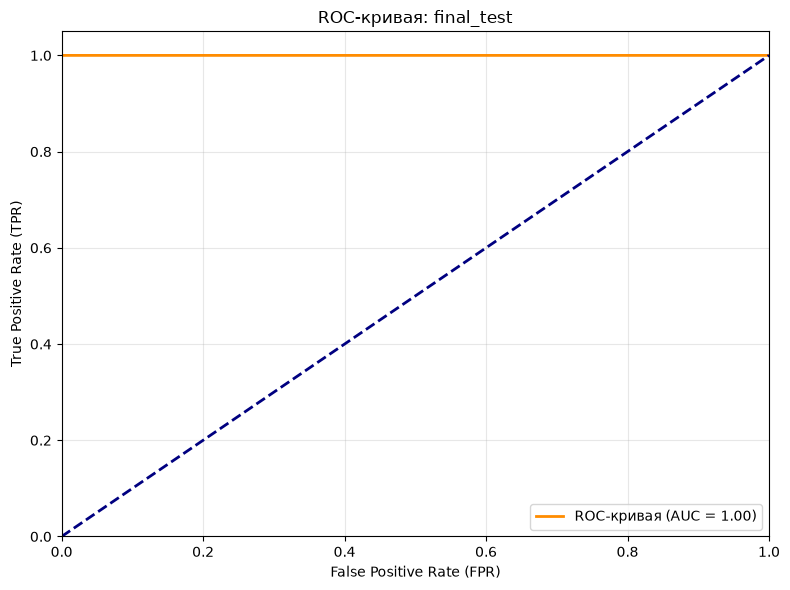

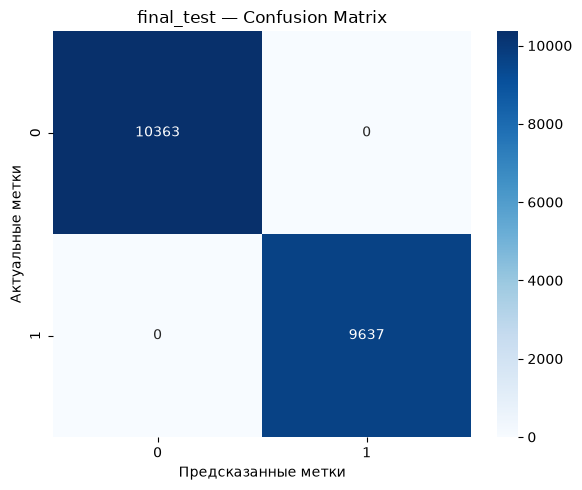

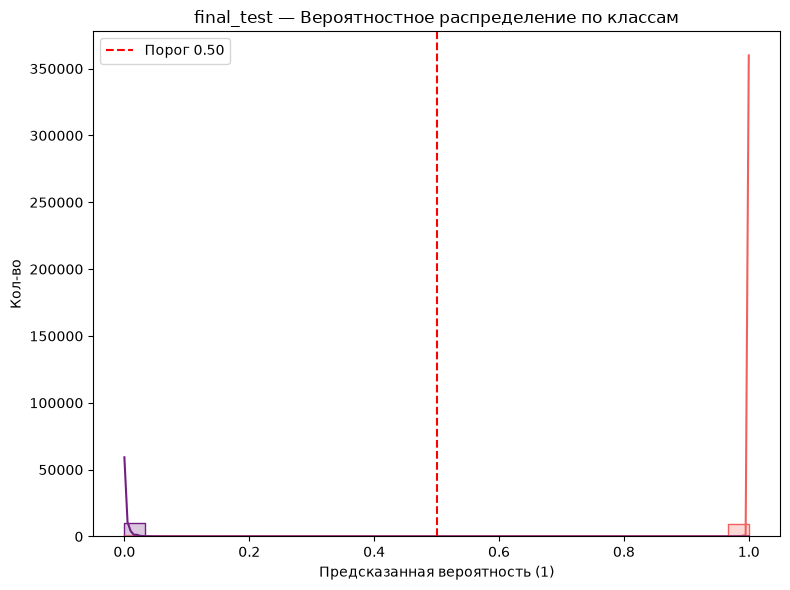

In [274]:
exp = mlflow.get_experiment_by_name("fraud_detection_classification")

runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    filter_string="attributes.status = 'FINISHED'",
    order_by=["metrics.roc_auc DESC"],
    max_results=5,
)

display(runs[["tags.mlflow.runName", "metrics.roc_auc", "metrics.f1", "run_id"]])

best_run_id = runs.iloc[0]["run_id"]
best_model = mlflow.sklearn.load_model(f"runs:/{best_run_id}/model")
evaluate_on_test(best_model, X_test, y_test, name="final_test")